In [1]:
import numpy as np
import pandas as pd 

In [2]:
pd.read_csv('spam.csv')

UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 606-607: invalid continuation byte

In [4]:
import pandas as pd
df = pd.read_csv('spam.csv', 
encoding='ISO-8859-1')

            

In [5]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing 
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. DATA CLEANING 

In [6]:
df= pd.read_csv('spam.csv',
encoding='ISO-8859-1')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
df.sample(5)

,v1,v2
3718,spam,"Thanks for your ringtone order, reference numb..."
3673,spam,You have won a Nokia 7250i. This is what you g...
1642,ham,Sleeping nt feeling well
3878,ham,She left it very vague. She just said she woul...
4723,spam,FREE GAME. Get Rayman Golf 4 FREE from the O2 ...


In [10]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
674,ham,"I've got &lt;#&gt; , any way I could pick up?"
5124,ham,He is impossible to argue with and he always t...
2538,ham,The monthly amount is not that terrible and yo...
1997,ham,\YEH I AM DEF UP4 SOMETHING SAT
5336,ham,Sounds better than my evening im just doing my...


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [12]:
df['target'] = encoder.fit_transform(df['target'])

In [13]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [15]:
# check for duplicate values
df.duplicated().sum()

403

In [16]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [17]:
df.duplicated().sum()

0

In [18]:
df.shape

(5169, 2)

## 2. EDA

In [19]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

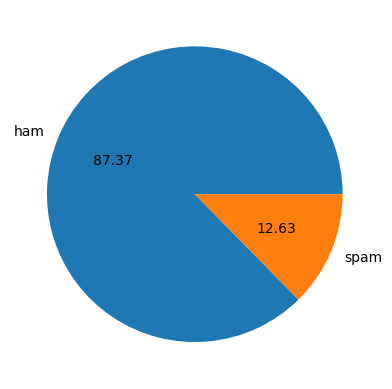

In [21]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [22]:
# Data is imbalanced 

In [23]:
import nltk

In [24]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [25]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/a81518fd-4e4b-4d9d-871c-
[nltk_data]     3e92bd130b61/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [26]:
df['num_characters'] = df['text'] .apply(len)

In [27]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [29]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [30]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [31]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [32]:
print(df.columns)

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='object')


In [33]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()
# ham 

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [35]:
# spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [36]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

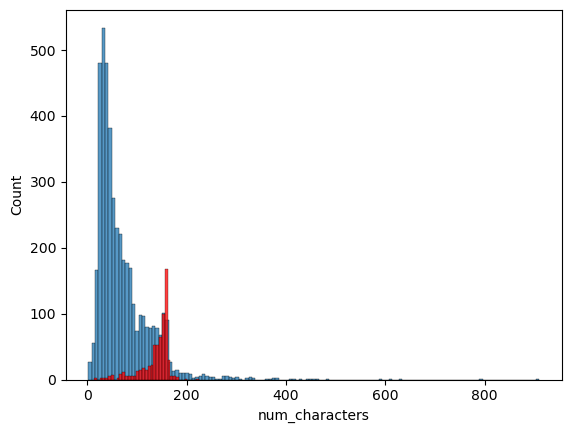

In [37]:
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


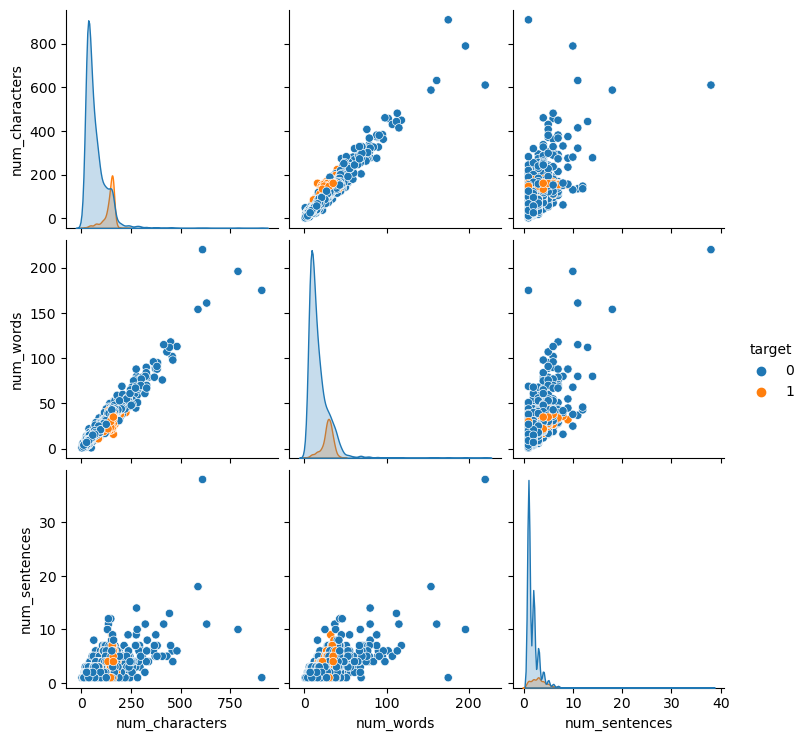

In [38]:
sns.pairplot(df,hue='target')

## 3. Data Preprocessing

# 1. Lower case
# 2. Tokenization
# 3. Removing special character
# 4. Stemming

In [39]:
import nltk
nltk.download('punkt') # this is downloads the tool needed for word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     /home/a81518fd-4e4b-4d9d-871c-
[nltk_data]     3e92bd130b61/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [40]:
import nltk

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = [] # Align this exactly with the lines above
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))

        
    return " ".join(y) # Align this with the 'for' and 'y = []'lines

In [41]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('singing')

'sing'

In [42]:
transform_text('I Loved the yt lectures on ml')

'i love the yt lectur on ml'

In [43]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='object')

In [44]:
df.columns = df.columns.str.strip()
# If your column is named 'v2', let's mke it 'text'

if 'v1' in df.columns:
    df.rename(columns={'v1' : 'target'},
inplace=True)
if 'v2' in df.columns:
    df.rename(columns={'v2': 'text'},
inplace=True)

df['transformed_text'] = df['text'].apply(transform_text)

In [45]:
df['transformed_text'] = df['text'].apply(transform_text)

In [46]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go until jurong point crazi avail onli in bugi...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri in 2 a wkli comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so earli hor u c alreadi then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah i do think he goe to usf he live around he...


In [47]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [48]:
df_temp = df['text'].value_counts().reset_index()
df_temp.columns = ['index',0]

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 137 (\x89) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
) missing from current font.el-2023.05-py310/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 139 (\x8b) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


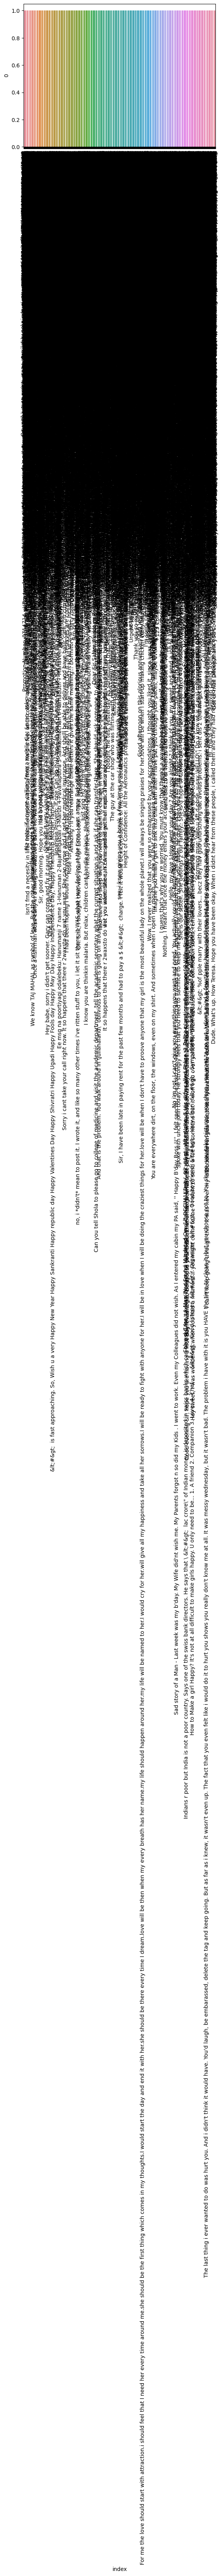

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
from wordcloud import WordCloud

# now your existing code will work
sns.barplot(x=df_temp['index'],
y=df_temp[0])

plt.xticks(rotation='vertical')
plt.show()

In [51]:
print(df[df['target'] == 1].shape)

(653, 6)


In [57]:
spam_msg_text = df[df['target'] == 1]['transformed_text'].str.cat(sep=" ")
spam_wc = wc.generate(spam_msg_text)

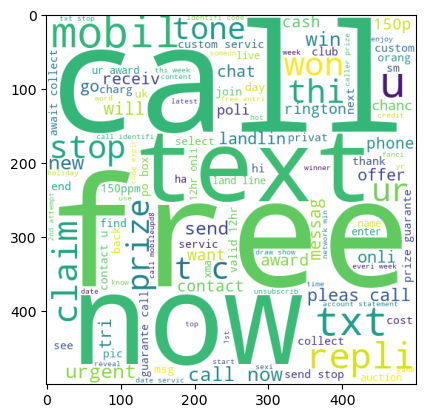

In [58]:
plt.imshow(spam_wc)

In [60]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

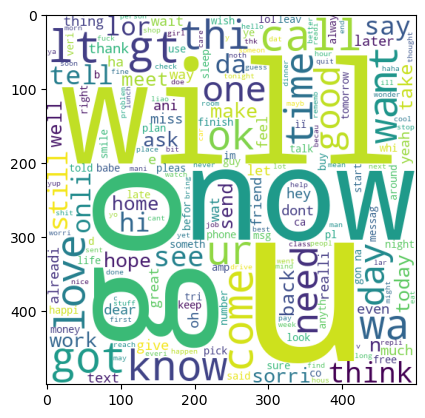

In [61]:
plt.imshow(ham_wc)

In [62]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go until jurong point crazi avail onli in bugi...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri in 2 a wkli comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so earli hor u c alreadi then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah i do think he goe to usf he live around he...


In [66]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [67]:
len(spam_corpus)

14475

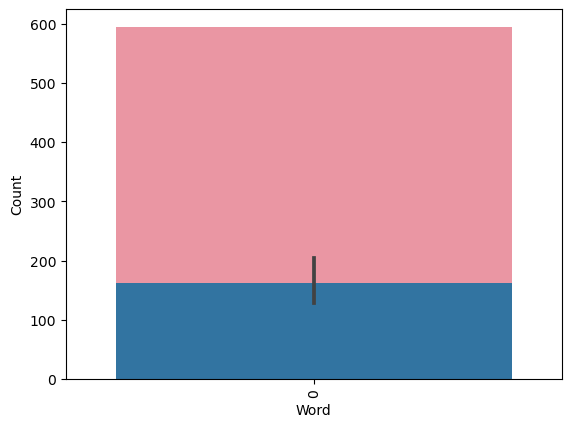

In [68]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
most_common_df.columns = ['Word','Count']
sns.barplot(x='Word', y='Count',
data=most_common_df)

sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

# 4. Model Building

In [69]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [70]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [71]:
X.shape

(5169, 6796)

In [72]:
y = df['target'].values

In [73]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2,random_state=2)

In [76]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [77]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [78]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8887814313346228
[[801  95]
 [ 20 118]]
0.5539906103286385


In [79]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9671179883945842
[[874  22]
 [ 12 126]]
0.8513513513513513


In [80]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9748549323017408
[[893   3]
 [ 23 115]]
0.9745762711864406


In [81]:
import pandas as pd

performance_df = pd.DataFrame({'Algorithm': ['BNB'], 'Accuracy' : [0.974], 'Precision' :[0.974]}).sort_values(by='Precision',ascending=False)
print(performance_df)

  Algorithm  Accuracy  Precision
0       BNB     0.974      0.974


In [85]:
def predict_spam(text):
       transformed_msg = transform_text(text)
       vector_input = cv.transform([transformed_msg])

       result = bnb.predict(vector_input)[0]

       if result == 1:
           return "spam"
       else:
            return "Not Spam"
           
print(predict_spam("Congratulations! you've won a $1000 walmart gift card. Click here to claim!"))

spam


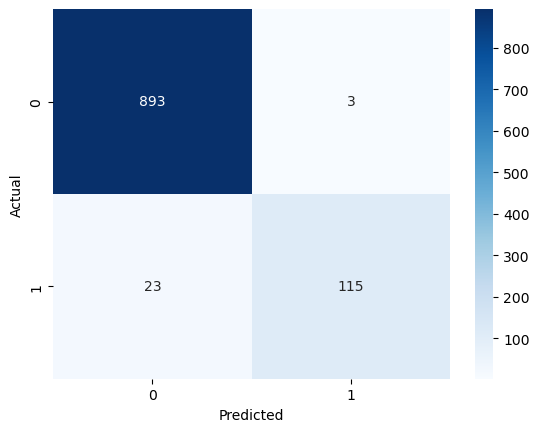

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred3)
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [87]:
import pickle
pickle.dump(cv, open('vectorizer.pkl','wb'))
pickle.dump(bnb, open('model.pkl', 'wb'))

In [89]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

print("MNB Precision:",precision_score(y_test, y_pred_mnb))

MNB Precision: 0.8513513513513513


In [90]:
pickle.dump(cv,open('vectorizer.pkl','wb'))
pickle.dump(bnb, open('model.pkl','wb'))

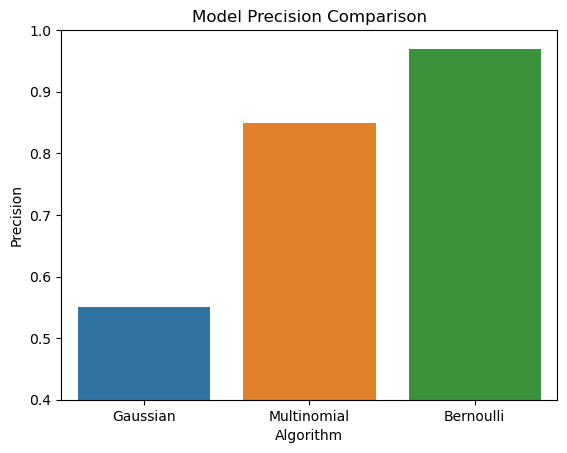

In [91]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

names = ['Gaussian', 'Multinomial', 'Bernoulli']
precision_scores = [0.55, 0.85, 0.97]

df_performance = pd.DataFrame({'Algorithm': names,'Precision': precision_scores})
sns.barplot(x='Algorithm', y='Precision',data=df_performance)
plt.ylim(0.4, 1.0)
plt.title('Model Precision Comparison')
plt.show()

In [124]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [125]:
import streamlit as st
import pickle
import string
from nltk.corpus import stopwords
import nltk
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
         if i not in stopwords.words('english') and i not in string.punctutation:
             y.append(i)
             
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
           
    return " ".join(y)

cv = pickle.load(open('vectorizer.pkl','rb'))
pickle.load(open('model.pkl','rb'))

st.title("SMS Spam Classifier")

input_sms = st.text_area("Enter the message")

if st.button('Predict'):
   transformed_sms = transform_text(input_sms)
   vector_input = cv.transform([transformed_sms])

   result = model.predict(vector_input)[0]

   if result == 1:
      st.header("Spam")
   else:
       st.header("Not Spam")



2026-03-11 08:09:52.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 08:09:52.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 08:09:52.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 08:09:52.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 08:09:52.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 08:09:52.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 08:09:52.079 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 08:09:52.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar